# RNN/LSTM Image Captioning

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / "src" / "rnn").exists()), cwd)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Users\HP 14s\Documents\1_FARHAN\1.SEM_6\ML\tubes-2\Tubes2ML_KicauMania


In [2]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to C:\Users\HP
[nltk_data]     14s\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\HP
[nltk_data]     14s\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Configuration

In [3]:
from src.rnn.paths import ARCH_TAG, RnnPaths

paths = RnnPaths.from_root(REPO_ROOT)
SEQ_LEN = 35
EVAL_LIMIT = 100
EPOCHS = 5
BATCH_SIZE = 64
RUN_TRAINING = False
FORCE_FEATURE_EXTRACTION = False

print(f"Architecture: {ARCH_TAG}")


Architecture: preinject_v2


## Feature Extraction

In [4]:
from src.rnn.feature_extraction import extract_and_save_repo_features
from src.rnn.experiment import load_feature_map

features_exist = paths.features_file.exists() and paths.feature_names_file.exists()
if FORCE_FEATURE_EXTRACTION or not features_exist:
    features_matrix, image_names = extract_and_save_repo_features(
        REPO_ROOT,
        batch_size=32,
        force=FORCE_FEATURE_EXTRACTION,
    )
else:
    print(f"Feature cache found: {paths.feature_dir}")

raw_image_features_map = load_feature_map(REPO_ROOT)
print(f"Loaded {len(raw_image_features_map)} raw image feature vectors")


Feature cache found: C:\Users\HP 14s\Documents\1_FARHAN\1.SEM_6\ML\tubes-2\Tubes2ML_KicauMania\images_feature
Loaded 8091 raw image feature vectors


## Caption Data

In [5]:
from src.rnn.experiment import load_caption_sequences, load_text_util
from src.rnn.training import prepare_training_data

text_util = load_text_util(REPO_ROOT, sequence_length=SEQ_LEN)
caption_mapping, sequence_mapping = load_caption_sequences(REPO_ROOT, text_util)
training_data = prepare_training_data(REPO_ROOT, sequence_length=SEQ_LEN)
image_features_map = training_data["image_features"]

print(f"Vocabulary size: {text_util.vocab_size}")
print(f"Captions mapped: {len(caption_mapping)} images")
print(f"Train/val/test: {len(training_data['train_keys'])}/{len(training_data['val_keys'])}/{len(training_data['test_keys'])}")
print(f"Scaled feature vectors ready: {len(image_features_map)}")


Vocabulary size: 8587
Captions mapped: 8091 images
Train/val/test: 6000/1000/1091
Scaled feature vectors ready: 8091


## Keras Training

In [6]:
from src.rnn.experiment import load_training_history
from src.rnn.training import train_all_variations

if RUN_TRAINING or not paths.training_history_file.exists():
    history_df = train_all_variations(
        REPO_ROOT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        sequence_length=SEQ_LEN,
        force=True,
    )
else:
    history_df = load_training_history(REPO_ROOT)

history_df[["architecture", "model_type", "variation_name", "layers", "hidden_state", "final_loss", "final_val_loss", "training_time_sec"]]

,architecture,model_type,variation_name,layers,hidden_state,final_loss,final_val_loss,training_time_sec
0,preinject_v2,SimpleRNN,Shallow_Small,1,128,1.318954,1.308966,41.007493
1,preinject_v2,SimpleRNN,Deep_Small,2,128,1.424180,1.390834,57.579876
2,preinject_v2,SimpleRNN,VeryDeep_Small,3,128,1.371136,1.346044,73.574900
3,preinject_v2,SimpleRNN,Shallow_Mid,1,256,1.187417,1.202435,50.514701
4,preinject_v2,SimpleRNN,Shallow_Large,1,512,1.084863,1.151079,74.142193
5,preinject_v2,SimpleRNN,Deep_Large,2,512,1.066879,1.146255,94.342647
6,preinject_v2,LSTM,Shallow_Small,1,128,1.517546,1.485829,29.733236
7,preinject_v2,LSTM,Deep_Small,2,128,1.828915,1.816912,32.594077
8,preinject_v2,LSTM,VeryDeep_Small,3,128,1.839263,1.833557,36.307908
9,preinject_v2,LSTM,Shallow_Mid,1,256,1.379611,1.355452,42.974389


## Scratch Caption Smoke Test

In [7]:
from src.rnn.ImageCaptioningScratch import ImageCaptioningModel
from src.rnn.experiment import make_keras_model

keras_model = make_keras_model(REPO_ROOT, text_util, "LSTM", "Shallow_Small", 1, 128)
scratch_model = ImageCaptioningModel(keras_model, text_util, is_lstm=True)

sample_image = training_data["test_keys"][0]
sample_caption = scratch_model.generate_caption(image_features_map[sample_image], max_len=10)
print(sample_image)
print(sample_caption)


c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2736508369_fd9ff0b42f.jpg
a man is in a man in a man in


## Full Evaluation

In [8]:
from src.rnn.experiment import (
    assert_anti_collapse_acceptance,
    compare_best_keras_vs_scratch,
    evaluate_all_variations,
    max_length_sweep,
    qualitative_samples,
    write_analysis_summary,
)


In [9]:
variation_results, caption_details = evaluate_all_variations(
    REPO_ROOT,
    split="test",
    limit=EVAL_LIMIT,
    max_len=SEQ_LEN,
)
variation_results.sort_values(["model_type", "scratch_bleu_4"], ascending=[True, False])

c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\sr

,architecture,model_type,variation_name,layers,hidden_state,scratch_bleu_4,scratch_meteor,scratch_total_time_sec,scratch_avg_time_sec,unique_captions,top_caption_frequency,training_time_sec,final_loss,final_val_loss
10,preinject_v2,LSTM,Shallow_Large,1,512,0.099047,0.308874,63.409567,0.634096,39,0.08,73.930653,1.260691,1.255882
9,preinject_v2,LSTM,Shallow_Mid,1,256,0.064762,0.263672,49.759255,0.497593,15,0.35,42.974389,1.379611,1.355452
6,preinject_v2,LSTM,Shallow_Small,1,128,0.063214,0.233888,21.646454,0.216465,10,0.36,29.733236,1.517546,1.485829
11,preinject_v2,LSTM,Deep_Large,2,512,0.051219,0.207164,145.671488,1.456715,65,0.23,88.796884,1.513245,1.483381
8,preinject_v2,LSTM,VeryDeep_Small,3,128,0.035378,0.111150,13.567703,0.135677,3,0.80,36.307908,1.839263,1.833557
7,preinject_v2,LSTM,Deep_Small,2,128,0.010187,0.094611,31.852933,0.318529,6,0.44,32.594077,1.828915,1.816912
4,preinject_v2,SimpleRNN,Shallow_Large,1,512,0.132539,0.330505,31.539803,0.315398,88,0.06,74.142193,1.084863,1.151079
5,preinject_v2,SimpleRNN,Deep_Large,2,512,0.112313,0.333898,67.405891,0.674059,80,0.09,94.342647,1.066879,1.146255
3,preinject_v2,SimpleRNN,Shallow_Mid,1,256,0.102162,0.304572,12.300239,0.123002,38,0.22,50.514701,1.187417,1.202435
0,preinject_v2,SimpleRNN,Shallow_Small,1,128,0.092006,0.272694,13.469488,0.134695,3,0.70,41.007493,1.318954,1.308966


In [10]:
keras_vs_scratch = compare_best_keras_vs_scratch(
    REPO_ROOT,
    split="test",
    limit=EVAL_LIMIT,
    max_len=SEQ_LEN,
)
keras_vs_scratch

c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,architecture,model_type,variation_name,layers,hidden_state,implementation,bleu_4,meteor,total_time_sec,avg_time_sec,unique_captions,top_caption_frequency
0,preinject_v2,LSTM,Shallow_Large,1,512,scratch,0.099047,0.308874,54.078588,0.540786,39,0.08
1,preinject_v2,LSTM,Shallow_Large,1,512,keras,0.099047,0.308874,477.331118,4.773311,39,0.08
2,preinject_v2,SimpleRNN,Shallow_Large,1,512,scratch,0.132539,0.330505,50.941247,0.509412,88,0.06
3,preinject_v2,SimpleRNN,Shallow_Large,1,512,keras,0.132539,0.330505,256.758462,2.567585,88,0.06


In [11]:
max_length_results = max_length_sweep(
    REPO_ROOT,
    lengths=(10, 20, 35),
    split="test",
    limit=EVAL_LIMIT,
)
max_length_results

c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\HP 14s\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,architecture,model_type,variation_name,implementation,max_len,bleu_4,meteor,total_time_sec,avg_time_sec,unique_captions,top_caption_frequency
0,preinject_v2,SimpleRNN,Shallow_Large,scratch,10,0.139177,0.326480,45.854098,0.458541,77,0.06
1,preinject_v2,SimpleRNN,Shallow_Large,scratch,20,0.132558,0.330539,56.975400,0.569754,88,0.06
2,preinject_v2,SimpleRNN,Shallow_Large,scratch,35,0.132539,0.330505,47.207758,0.472078,88,0.06


In [12]:
samples = qualitative_samples(REPO_ROOT, limit=EVAL_LIMIT, n_per_bucket=4)
samples

,architecture,image_name,bleu_4_LSTM,bleu_4_SimpleRNN,generated_caption_LSTM,generated_caption_SimpleRNN,avg_bleu_4,ground_truth
0,preinject_v2,2335619125_2e2034f2c3.jpg,0.728955,0.840896,a dog is running through the snow,a black dog is running through the grass,0.784925,<start> a big black dog bares its teeth while ...
1,preinject_v2,2886411666_72d8b12ce4.jpg,0.349964,0.598553,a dog is running through the grass,a dog runs through the grass,0.474258,<start> a black brown and white dog is running...
2,preinject_v2,950273886_88c324e663.jpg,0.519307,0.289978,a man in a red shirt is jumping on a rock,a man in a blue shirt is standing on a rock,0.404643,<start> a man grasps onto the rock face <end> ...
3,preinject_v2,2148916767_644ea6a7fa.jpg,0.194413,0.454994,a black dog is running through the grass,a dog is running through the snow,0.324704,<start> a black and white dog playing in the s...
4,preinject_v2,3640109324_3ce89e4d1a.jpg,0.007743,0.014400,a man in a red shirt and a black and white and...,a man in a red shirt and a woman in a red shir...,0.011071,<start> a group of men carry a silver coffin <...
5,preinject_v2,537359971_6e28f5e66e.jpg,0.020469,0.011713,a man in a black shirt is standing on a sidewalk,a woman in a white shirt and a woman in a red ...,0.016091,<start> two woman wearing skirts walking down ...
6,preinject_v2,467858872_f3431df682.jpg,0.016670,0.017681,a dog is running through the snow,a small dog is running through the water,0.017175,<start> two dogs are bending over and looking ...
7,preinject_v2,2244551043_21b8cca866.jpg,0.014558,0.028339,a man in a red shirt and a black and white and...,a man in a red shirt and a woman in a red shir...,0.021449,<start> four people are lining up to purchase ...
8,preinject_v2,226607225_44d696db6b.jpg,0.072012,0.067014,a dog is running through the water,a man is jumping over a hurdle,0.069513,<start> a green fish is jumping out of water <...
9,preinject_v2,3431101934_99a6c55914.jpg,0.068407,0.071759,a young boy is jumping on a rock,a girl in a blue shirt is jumping on a swing,0.070083,<start> one little girl dressed in pink watche...


In [13]:
acceptance = assert_anti_collapse_acceptance(REPO_ROOT)
display(acceptance[["model_type", "variation_name", "unique_captions", "top_caption_frequency"]])

summary_path = write_analysis_summary(REPO_ROOT)
print(f"Ringkasan analisis disimpan di: {summary_path}")


,model_type,variation_name,unique_captions,top_caption_frequency
10,LSTM,Shallow_Large,39,0.08
4,SimpleRNN,Shallow_Large,88,0.06


Ringkasan analisis disimpan di: C:\Users\HP 14s\Documents\1_FARHAN\1.SEM_6\ML\tubes-2\Tubes2ML_KicauMania\artifacts\rnn\results\analysis_summary.md


## Training Curves

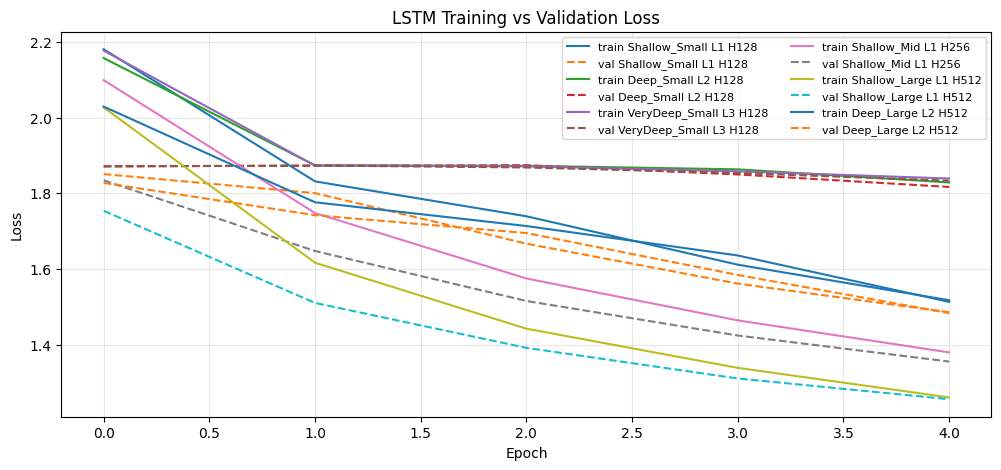

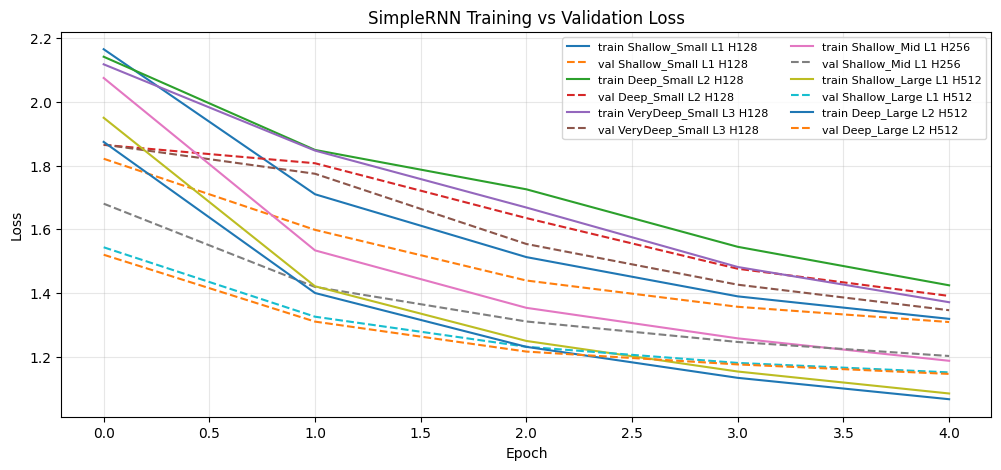

In [14]:
from src.rnn.visualization import plot_training_history

plot_training_history(REPO_ROOT)